### LeNet-5 Architecture:
- LeNet-5 is a foundational convolutional neural network(CNN) architecture.
- It consists of seven layers, including
  - two convolutional layers,
  - two average pooling (subsampling) layers,
  - one flattening convolutional layer,
  - two fully connected layers,
  - culminating in a softmax output layer.
### Layer-by-Layer Breakdown:
#### C1(Convolutional Layer):
- Applies 6 filters of size 5x5 to a 32x32x1 grayscale input, producing 28x28x6 feature maps.
- Uses tanh activation.
- Has 156 trainable parameters.
#### S1(Average Pooling):
- Reduces spatial dimensions using 2x2 kernels with stride 2, resulting in 14x14x6 output.
- Has 12 trainable paramters(weights and biases).
#### C2(Convolutional Layer):
- Applies 16 filters of size 5x5 to a 14x14x6 input, producing 10x10x16 feature maps.
- Uses tanh activation.
- Has 2,416 trainable parameters.
#### S2(Average Pooling):
- Reduces spatial dimensions using 2x2 kernel with stride 2, resulting in 5x5x16 output.
- Has 32 trainable paramters.
#### C3(Convolutional Layer):
- Applies 120 filters of size 4x4(or 5x5 with no padding) to produce 1x1x120 output.
- This layer uses non-uniform connections-each output map connects to a subset of input maps from S2, enabling(To do something) feature combination.
- Has 19,320 trainable paramters.
#### F6(Fully Connected Layer):
- 84 neurons connected to the 120-unit output of C3.
- Uses tanh activation.
- Has 10,164 paramters.
#### Output(softmax Layer):
- 10 neurons for digit classification(0-9), using softmax activation.
- Has 850 Paramters.

### Implementation of LeNet-5:

C:\Users\techs\anaconda3\New folder\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.9075 - loss: 0.3207
Epoch 2/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.9572 - loss: 0.1432
Epoch 3/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.9711 - loss: 0.0965
Epoch 4/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9787 - loss: 0.0707
Epoch 5/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9819 - loss: 0.0576
Epoch 6/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.9856 - loss: 0.0474
Epoch 7/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9884 - loss: 0.0388
Epoch 8/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.9898 - loss: 0.0334
Epoch 9/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9911 - loss: 0.0297
Epoch 10/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9919 - loss: 0.0260
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9882 - loss: 0.0386   
Test Loss:
 0.038550060242414474
313/313 ━━━━━━━━━━━━━━━━━━━━

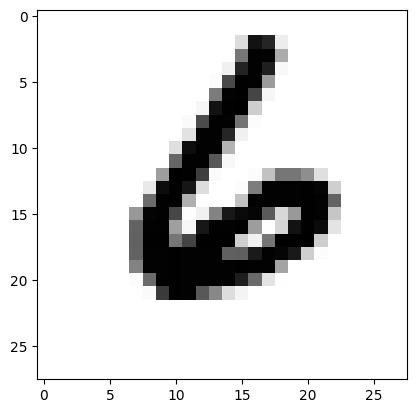

In [3]:
# Importing Required Libraries:
import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf

# Loading the dataset and perform splitting
mnist = tf.keras.datasets.mnist
(x_train, y_train), (x_test, y_test) = mnist.load_data()

rows, cols = 28, 28

# Reshape the data into a 4D Array
x_train = x_train.reshape(x_train.shape[0], rows, cols, 1)
x_test = x_test.reshape(x_test.shape[0], rows, cols, 1)

input_shape = (rows, cols, 1)

# Set type as float32 and normalize the values to [0,1]
x_train = x_train.astype('float32')
x_test = x_test.astype('float32')
x_train = x_train / 255.0
x_test = x_test / 255.0

# Transform labels to one hot encoding
y_train = tf.keras.utils.to_categorical(y_train, 10)

def build_lenet(input_shape):
    # Define Sequential Layer
    model = tf.keras.Sequential()

    # C1 Convolution Layer
    model.add(tf.keras.layers.Conv2D(filters=6, kernel_size=(5,5), strides=(1,1),
                                     activation='tanh', input_shape=input_shape))

    # S2 SubSampling Layer
    model.add(tf.keras.layers.AveragePooling2D(pool_size=(2,2), strides=(2,2)))

    # C3 Convilution Layer
    model.add(tf.keras.layers.Conv2D(filters=16, kernel_size=(5,5), strides=(1,1),
                                     activation='tanh', input_shape=input_shape))

    # S4 SubSampling Layer
    model.add(tf.keras.layers.AveragePooling2D(pool_size=(2,2), strides=(2,2)))

    # C5 Fully Connected Layer
    model.add(tf.keras.layers.Dense(units=120, activation='tanh'))

    # Flatten the output so that we can connect it with the fully- 
    # connected layers by converting it into a 1D Array
    model.add(tf.keras.layers.Flatten())

    # FC6 Fully Connected Layers
    model.add(tf.keras.layers.Dense(units=84, activation='tanh'))

    # Output Layer
    model.add(tf.keras.layers.Dense(units=10, activation='softmax'))

    return model

lenet = build_lenet(input_shape)

# Compile the model
lenet.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# We will be allowing 10 itterations to happen
epochs = 10
history = lenet.fit(x_train, y_train, epochs=epochs, batch_size=128, verbose=1)

# Check Accuracy of the Model
# Transform labels to one hot encoding
if len(y_test.shape)!=2 or y_test.shape[1]!=10:
    y_test = tf.keras.utils.to_categorical(y_test, 10)
    

loss = lenet.evaluate(x_test, y_test)
print('Test Loss:\n', loss[0])
acc = lenet.evaluate(x_test, y_test)
print('Test Accuracy:\n', acc[1])

x_train = x_train.reshape(x_train.shape[0], 28, 28)
print('Training Data:\n', x_train.shape, y_train.shape)
x_test = x_test.reshape(x_test.shape[0], 28, 28)
print('Test Data:\n', x_test.shape, y_test.shape)

# Plot the Image
image_index = 8888
plt.imshow(x_test[image_index].reshape(28,28), cmap='Greys')

# Make Prediction
pred = lenet.predict(x_test[image_index].reshape(1, rows, cols, 1))
pred_argmax = pred.argmax()
print('Preidct Argmax:\n', pred_argmax)